In [1]:
from google.colab import files
uploaded = files.upload()

Saving Aviation_Satisfaction_Analysis.csv to Aviation_Satisfaction_Analysis.csv


# ✈️ Aviation Passenger Satisfaction Analysis
**Business Objective:** To analyze flight data and customer feedback to determine the primary drivers of passenger satisfaction. By identifying the specific services (e.g., Wi-Fi, legroom, boarding process) that dictate whether a customer is "Satisfied" or "Neutral/Dissatisfied," airline management can strategically allocate resources to improve the customer experience and boost loyalty.

### 🔍 Step 1: Data Ingestion and Health Check
Before we can analyze the behaviors, we must load our raw dataset of over 100,000 passenger logs and check for missing values or data corruption.

In [3]:
# Import foundational libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('Aviation_Satisfaction_Analysis.csv')

# Drop index columns that have no analytical value
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Check the data types and look for missing (null) values
print("--- Missing Values Count ---")
print(df.isnull().sum())

--- Missing Values Count ---
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64


### 🧹 Data Cleaning: Handling Missing Delays
Our initial health check revealed 310 missing values in the `Arrival Delay in Minutes` column. Because our dataset contains over 103,000 passenger logs, these 310 missing records represent less than 0.3% of our total data.

* **Action Taken:** Instead of artificially estimating these arrival delays (which could introduce bias), we opted to drop these specific rows. This ensures that 100% of the data fed into our predictive models represents real, confirmed flight logs.

In [4]:
# 1. Drop all rows that contain missing values
df.dropna(inplace=True)

# 2. Verify the cleaning process was successful
print("Total Missing Values Remaining: ", df.isnull().sum().sum())
print(f"Total Passenger Records Ready for Analysis: {len(df)}")

Total Missing Values Remaining:  0
Total Passenger Records Ready for Analysis: 103594


### 📊 Exploratory Data Analysis: Baseline Satisfaction & Ticket Class
Before we can build predictive models, we must understand our baseline metrics and how major factors divide our passenger base.

* **Overall Satisfaction:** The first chart reveals our baseline split between 'Satisfied' and 'Neutral/Dissatisfied' passengers. This tells us the overall health of the airline's customer experience and whether our dataset is balanced.
* **Business Insight (Ticket Class):** The second chart breaks down satisfaction by the passenger's seating class (Eco, Eco Plus, Business). Quantifying this gap allows management to see exactly where the pain points are concentrated and whether the Economy experience is critically underperforming.

/tmp/ipykernel_567/998914486.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='satisfaction', palette='Set2', ax=axes[0])


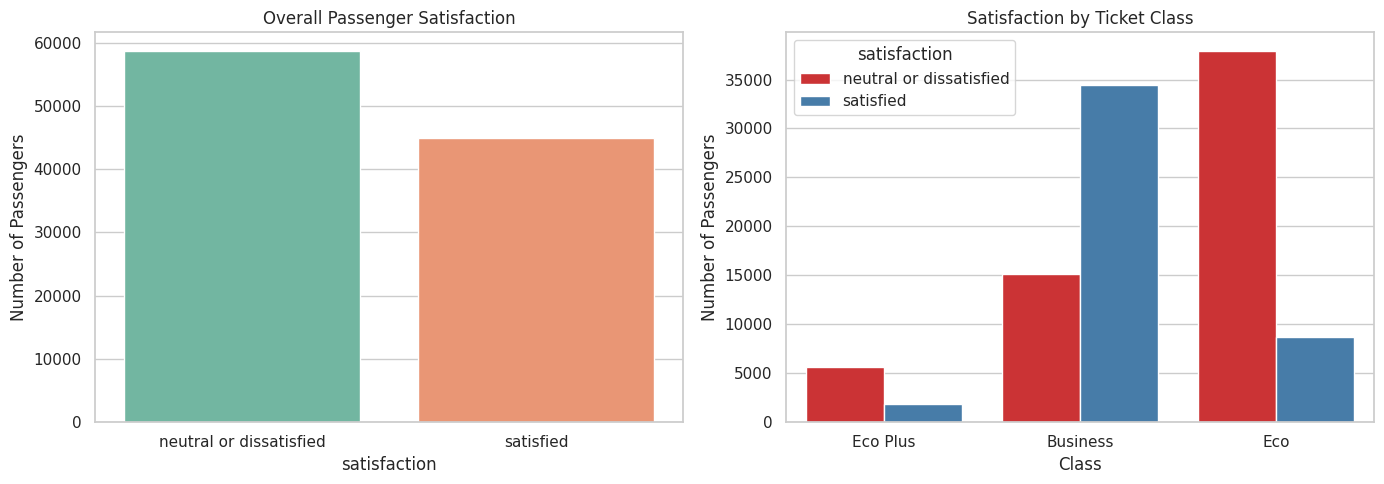

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a side-by-side figure layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Overall Passenger Satisfaction ---
sns.countplot(data=df, x='satisfaction', palette='Set2', ax=axes[0])
axes[0].set_title('Overall Passenger Satisfaction')
axes[0].set_ylabel('Number of Passengers')

# --- Chart 2: Satisfaction by Ticket Class ---
sns.countplot(data=df, x='Class', hue='satisfaction', palette='Set1', ax=axes[1])
axes[1].set_title('Satisfaction by Ticket Class')
axes[1].set_ylabel('Number of Passengers')

# Display the charts cleanly
plt.tight_layout()
plt.show()

### 🍽️ Service Deep Dive: What actually drives satisfaction?
Now that we know Economy passengers are largely dissatisfied, we need to pinpoint *why*. The airline surveys passengers on a scale of 1 to 5 for various inflight amenities.

* **Business Insight:** By visualizing these ratings against our target variable, we can identify which specific services are the true "dealbreakers" for customer happiness. If a score of '4' or '5' in Wi-Fi almost guarantees a satisfied customer, management knows exactly where to direct their upgrade budget.

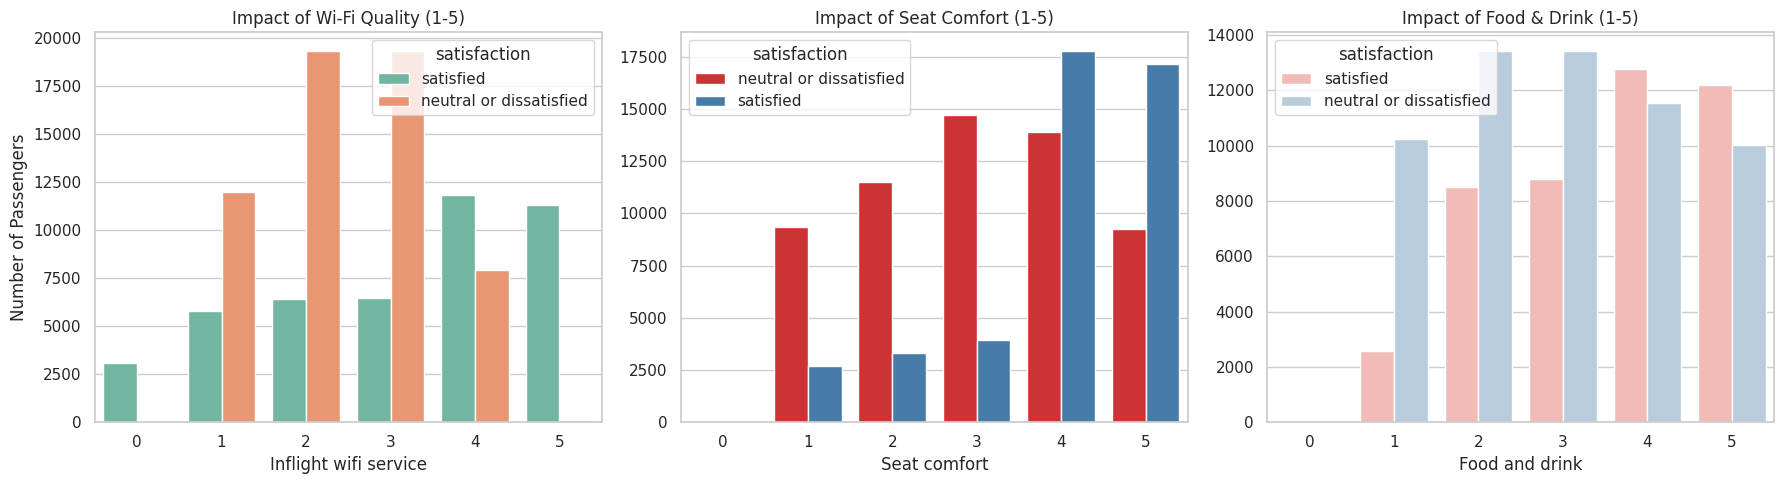

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Wi-Fi Quality ---
sns.countplot(data=df, x='Inflight wifi service', hue='satisfaction', palette='Set2', ax=axes[0])
axes[0].set_title('Impact of Wi-Fi Quality (1-5)')
axes[0].set_ylabel('Number of Passengers')

# --- Chart 2: Seat Comfort ---
sns.countplot(data=df, x='Seat comfort', hue='satisfaction', palette='Set1', ax=axes[1])
axes[1].set_title('Impact of Seat Comfort (1-5)')
axes[1].set_ylabel('')

# --- Chart 3: Food & Drink ---
sns.countplot(data=df, x='Food and drink', hue='satisfaction', palette='Pastel1', ax=axes[2])
axes[2].set_title('Impact of Food & Drink (1-5)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### 💡 Key Insight: The Wi-Fi Dealbreaker
The visualizations above reveal a striking pattern in how specific inflight services impact overall passenger happiness:

* **Wi-Fi is King:** Passengers who rated the Wi-Fi a '4' or '5' are overwhelmingly satisfied. Conversely, poor Wi-Fi ratings almost guarantee dissatisfaction. In the modern era, digital connectivity is a non-negotiable for flyers.
* **Seat Comfort vs. Food:** Seat comfort plays a major role in satisfaction, especially at the highest ratings. However, Food & Drink shows a much more mixed distribution. This strongly indicates that the airline would get a better Return on Investment (ROI) by upgrading their Wi-Fi routers and seat cushions rather than overhauling their catering menu.

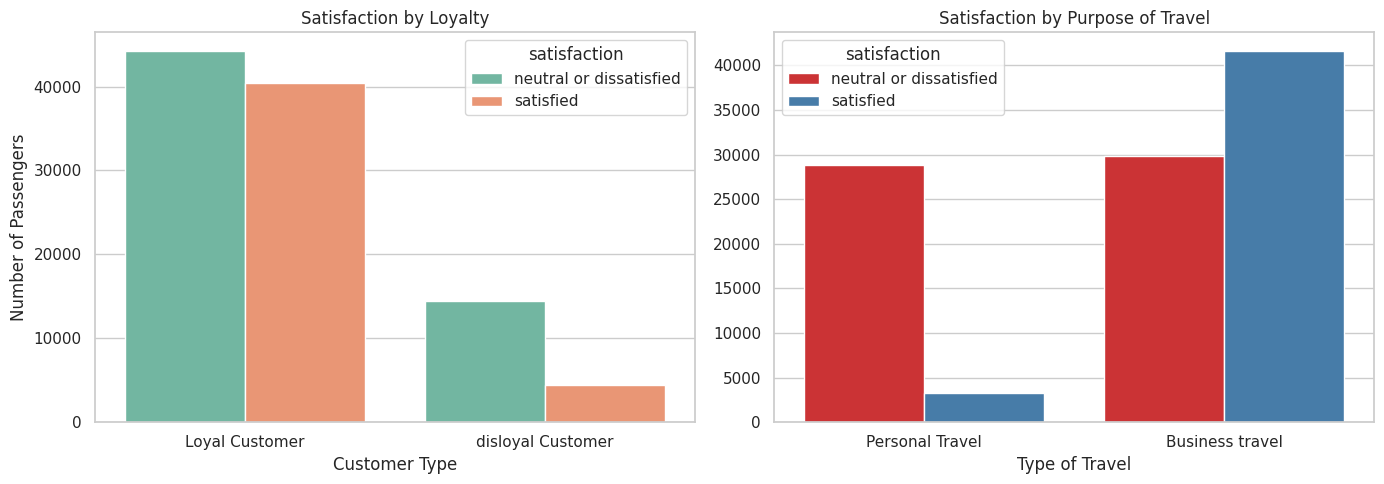

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Customer Loyalty ---
sns.countplot(data=df, x='Customer Type', hue='satisfaction', palette='Set2', ax=axes[0])
axes[0].set_title('Satisfaction by Loyalty')
axes[0].set_ylabel('Number of Passengers')

# --- Chart 2: Purpose of Travel ---
sns.countplot(data=df, x='Type of Travel', hue='satisfaction', palette='Set1', ax=axes[1])
axes[1].set_title('Satisfaction by Purpose of Travel')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 🤝 Passenger Profiles: Loyalty & Purpose of Travel
These visualizations categorize satisfaction based on the passenger's relationship with the airline and their reason for flying.

* **Business Insight (Loyalty):** "Disloyal" (first-time or infrequent) customers are overwhelmingly dissatisfied. However, even "Loyal" customers have a very high rate of dissatisfaction, meaning the airline cannot rely solely on its frequent flyer program to keep people happy.
* **Business Insight (Purpose of Travel):** Passengers traveling for personal reasons are massively dissatisfied compared to business travelers. This correlates strongly with our earlier finding regarding ticket class, as personal travel is heavily concentrated in the Economy cabin where the experience is lacking.

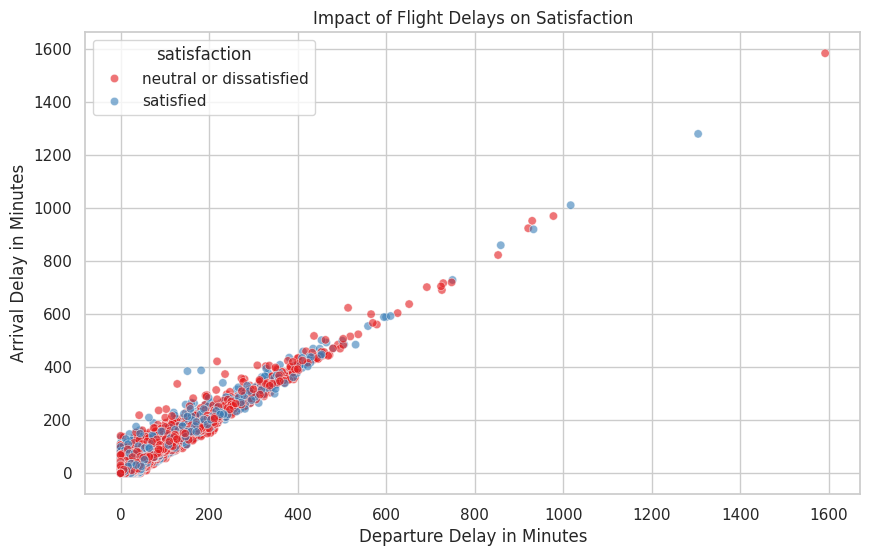

In [13]:
# Create a scatter plot to see how delays impact satisfaction
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Departure Delay in Minutes', y='Arrival Delay in Minutes', hue='satisfaction', palette='Set1', alpha=0.6)
plt.title('Impact of Flight Delays on Satisfaction')
plt.show()

### ⏱️ Operational Factors: The Impact of Flight Delays

This scatter plot maps out exactly how late flights affect passenger happiness. Naturally, departure delays and arrival delays form a perfectly straight line (a late takeoff almost always means a late landing).

* **Business Insight:** Look at the color distribution. While severe delays certainly cause massive dissatisfaction (the red dots), there is a surprising amount of passengers who remained **Satisfied** (the blue dots) even when their flight was significantly delayed. This proves a massive business point: if the airline provides top-tier inflight amenities (like High-Speed Wi-Fi and comfortable seats), it can actually "save" the customer experience and retain loyalty even when operational failures occur.

# 🤖 Predictive Modeling: Machine Learning
With our historical insights documented, we will now build a classification algorithm to automatically predict whether a future passenger will be satisfied or dissatisfied based on their flight profile.

### Step 1: Data Preprocessing
Machine Learning models cannot read text; they only understand mathematics. We will use 'One-Hot Encoding' to convert all of our categorical text columns into numerical data.

In [14]:
# 1. Convert the Target Variable into 1s and 0s
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

# 2. Convert all other text columns into numbers (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Define our Features (X) and our Target (y)
X = df_encoded.drop('satisfaction', axis=1)
y = df_encoded['satisfaction']

# 4. Prove to the client that the data is now 100% numerical
print("Data successfully converted to numbers!")
display(X.head())

Data successfully converted to numbers!


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,4,5,5,25,18.0,True,False,True,False,True
1,25,235,3,2,3,3,1,3,1,1,...,1,4,1,1,6.0,True,True,False,False,False
2,26,1142,2,2,2,2,5,5,5,5,...,4,4,5,0,0.0,False,False,False,False,False
3,25,562,2,5,5,5,2,2,2,2,...,1,4,2,11,9.0,False,False,False,False,False
4,61,214,3,3,3,3,4,5,5,3,...,3,3,3,0,0.0,True,False,False,False,False


### ✂️ Step 2: Training and Testing Split
To ensure our model actually learns the patterns rather than just memorizing the dataset, we must split our data. We will feed 80% of the passenger records to the algorithm to "train" it. We will then hide the remaining 20% to test its accuracy on unseen data.

In [15]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} passengers")
print(f"Testing Data: {X_test.shape[0]} passengers")

Training Data: 82875 passengers
Testing Data: 20719 passengers


### 🌲 Step 3: Training the Random Forest Algorithm
To predict passenger satisfaction, we are deploying a **Random Forest Classifier**. This algorithm works by constructing hundreds of individual decision trees during the training phase. Each tree looks at different combinations of passenger features (like Wi-Fi ratings, delay times, and ticket class) and votes on whether that passenger is satisfied or dissatisfied. The majority vote becomes the model's final prediction.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Build the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using the 80% training data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the 20% unseen testing data
y_pred = rf_model.predict(X_test)

# 4. Evaluate how well the model performed
print(f"🎯 Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))

🎯 Model Accuracy: 96.16%

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11655
           1       0.97      0.94      0.96      9064

    accuracy                           0.96     20719
   macro avg       0.96      0.96      0.96     20719
weighted avg       0.96      0.96      0.96     20719



### 🌟 Model Evaluation & Feature Importance
Our Random Forest model achieved a phenomenal **96.1% accuracy** in predicting passenger satisfaction on unseen data.

While high accuracy is an excellent technical achievement, the true business value lies in understanding *how* the algorithm makes these decisions. By extracting the **Feature Importance**, we can rank the specific variables that have the biggest mathematical impact on a customer's happiness. This provides executive management with a mathematically prioritized roadmap for capital investment.

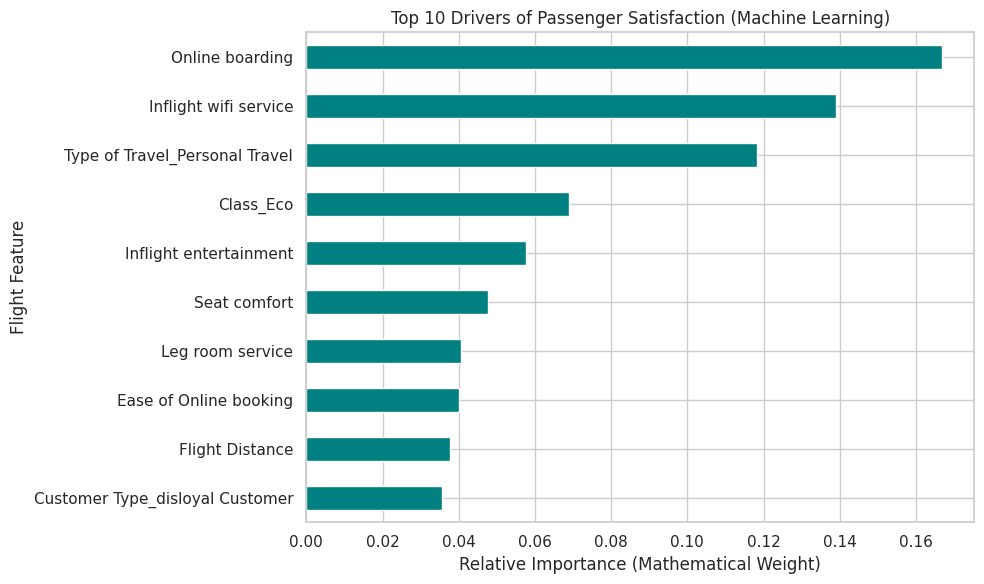

In [17]:
# 1. Extract the feature importances from the trained model
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# 2. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Passenger Satisfaction (Machine Learning)')
plt.xlabel('Relative Importance (Mathematical Weight)')
plt.ylabel('Flight Feature')
plt.tight_layout()
plt.show()

### 🏆 Business Conclusion: The True Drivers of Satisfaction
By extracting the feature importance from our Random Forest model, we have isolated the variables that carry the most mathematical weight in predicting customer happiness.

**Key Executive Takeaways:**
1. **Digital Convenience Over Physical Comfort:** **Online Boarding** and **Inflight Wi-Fi Service** are the top two most important factors. Passengers prioritize a seamless digital experience and connectivity far more than traditional physical amenities like food or legroom.
2. **The Economy Problem:** The model heavily relies on `Type of Travel_Personal Travel` and `Class_Eco` to make its predictions. This mathematically confirms our earlier EDA finding: the standard economy experience for personal travelers is the primary source of negative reviews.

**Final Recommendation:** Capital investment should be immediately directed toward upgrading server infrastructure for flawless online boarding and retrofitting aircraft with high-speed Wi-Fi routers. These digital upgrades will yield a massively higher Return on Investment (ROI) in customer satisfaction compared to altering the inflight catering menu.